In [1]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models("all")
benchmarks = ['fungi_tastic_2025']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

File not found:  /research/haider/.cache/unibench/outputs/chameleon_7b/fungi_tastic_2025.f
File not found:  /research/haider/.cache/unibench/outputs/llava_1_5_7b/fungi_tastic_2025.f
File not found:  /research/haider/.cache/unibench/outputs/llava_next_llama_8b/fungi_tastic_2025.f
File not found:  /research/haider/.cache/unibench/outputs/paligemma_3b_224/fungi_tastic_2025.f
File not found:  /research/haider/.cache/unibench/outputs/paligemma_3b_mix_224/fungi_tastic_2025.f


In [3]:
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

/tmp/ipykernel_72104/3339113372.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


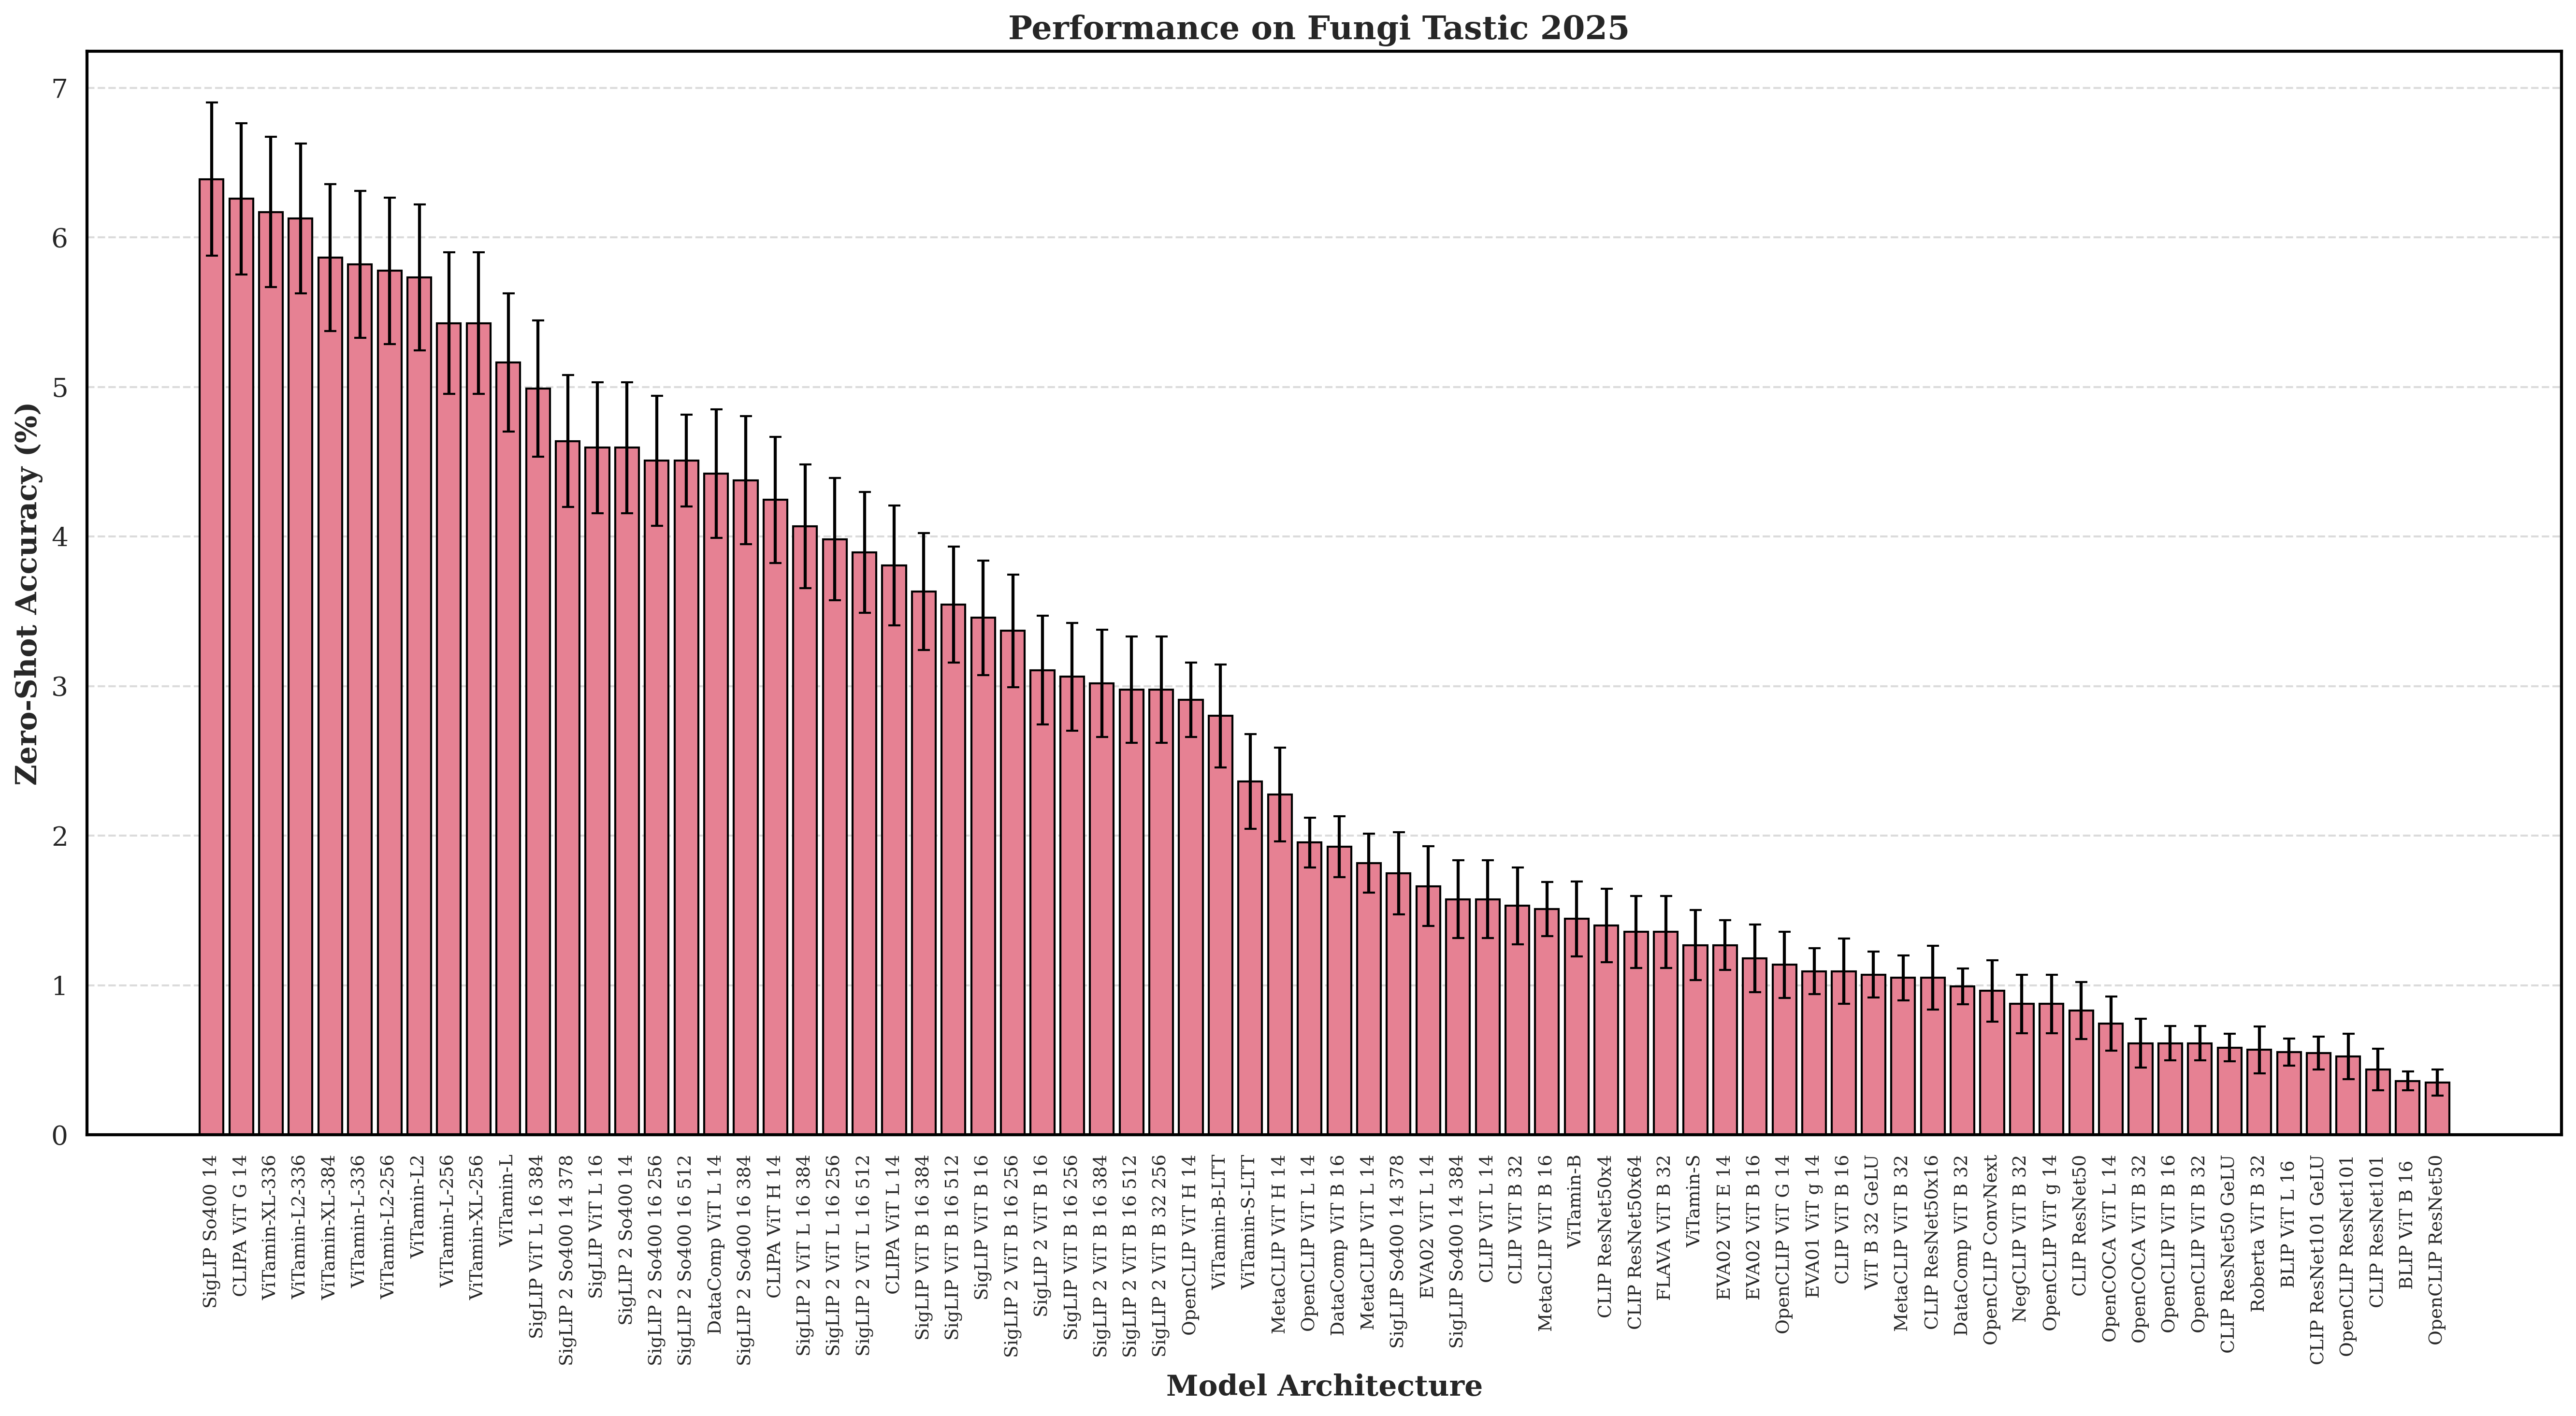

In [4]:
# Create dataframe with average performance across all benchmarks
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

# Calculate overall performance for each model
overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

# Create model data DataFrame
model_data = pd.DataFrame({
    'model_name': overall_performance.index, 
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# Set up the plot with publication-ready styling
plt.figure(figsize=(18, 10), dpi=300)
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Use a consistent color for all bars
color = sns.color_palette("husl", 1)[0]

# Create the barplot with error bars
ax = sns.barplot(
    x='model_name', 
    y='performance', 
    data=sorted_models,
    color=color,
    edgecolor='black',
    linewidth=1
)

# Add error bars
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black', capsize=3, elinewidth=1.5)

# Customize the plot
plt.xticks(rotation=90, ha='center', fontsize=9)
plt.xlabel('Model Architecture', fontweight='bold')
plt.ylabel('Zero-Shot Accuracy (%)', fontweight='bold')
plt.title('Performance on Fungi Tastic 2025 ', fontweight='bold', fontsize=16)

# Format x-axis labels - show abbreviated model names
labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]
ax.set_xticklabels(labels)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add overall average performance annotation
avg_performance = sorted_models['performance'].mean()
# textstr = f"Overall Average Performance: {avg_performance:.2f}%"
props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
# plt.annotate(textstr, xy=(0.02, 0.02), xycoords='axes fraction', bbox=props, fontsize=9)

plt.tight_layout()
plt.show()


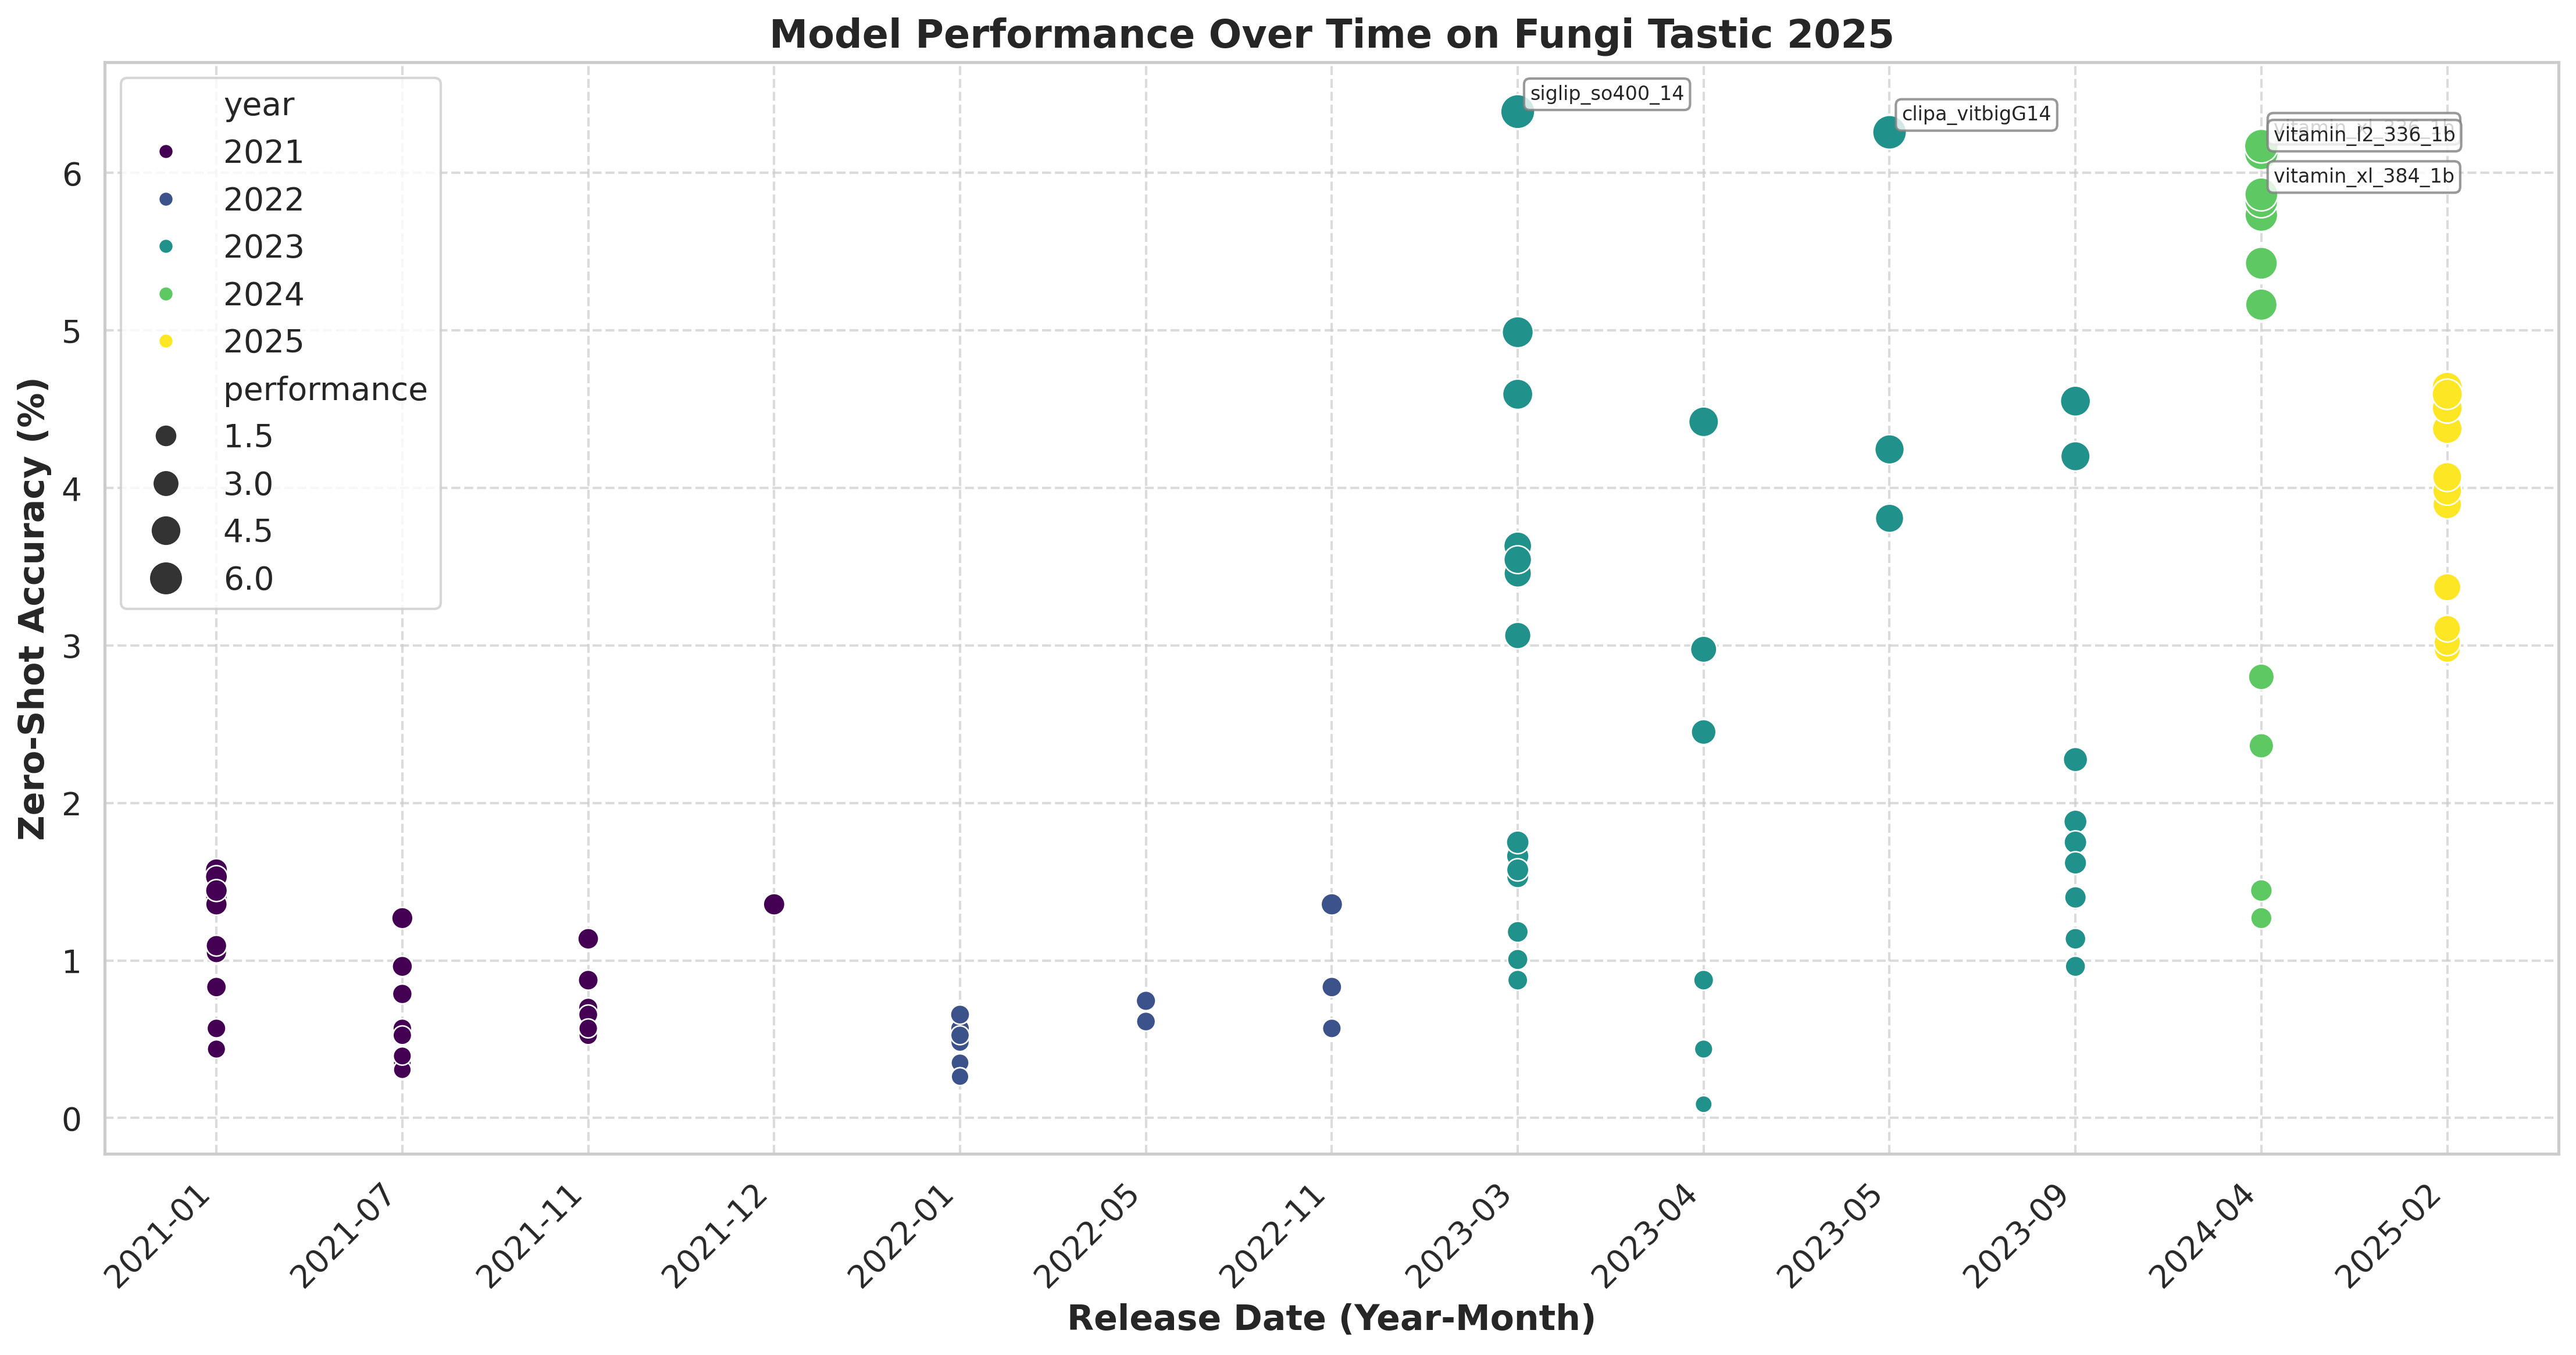

In [10]:
model_mappings = get_model_mappings('year')

results['year'] = results["model_name"].map(model_mappings)
model_mappings = get_model_mappings('month')
results['month'] = results["model_name"].map(model_mappings)
# Create a time column combining year and month 
results['time'] = results['year'].astype(str) + '-' + results['month'].astype(str).str.zfill(2)

# Calculate average performance per model by time
time_perf = results.groupby(['model_name'])['correctness'].mean().reset_index()

# Join with time information (taking first occurrence of each model)
model_times = results.drop_duplicates('model_name')[['model_name', 'time', 'year', 'month']]
time_perf = time_perf.merge(model_times, on='model_name')

# Convert performance to percentage
time_perf['performance'] = time_perf['correctness'] * 100

# Sort by time
time_perf['time_sort'] = time_perf['year'] * 100 + time_perf['month'].astype(int)
time_perf = time_perf.sort_values('time_sort')

# Set up plot
plt.figure(figsize=(15, 8), dpi=300)
sns.set(style="whitegrid", font_scale=1.2)

# Create scatter plot with connected lines
# plt.plot(time_perf['time'], time_perf['performance'], '-', alpha=0.5, color='gray')
scatter = sns.scatterplot(
    data=time_perf,
    x='time', 
    y='performance',
    hue='year',  # Color by year
    size='performance',  # Size by performance
    sizes=(50, 200),
    palette='viridis'
)

# Format the plot
plt.xticks(rotation=45, ha='right')
plt.xlabel('Release Date (Year-Month)', fontweight='bold')
plt.ylabel('Zero-Shot Accuracy (%)', fontweight='bold')
plt.title('Model Performance Over Time on Fungi Tastic 2025', fontweight='bold', fontsize=16)

# Add grid and adjust layout
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Add annotations for top-performing models
for idx, row in time_perf.nlargest(5, 'performance').iterrows():
    plt.annotate(
        row['model_name'],
        xy=(row['time'], row['performance']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )

plt.show()


/tmp/ipykernel_72104/3066618740.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


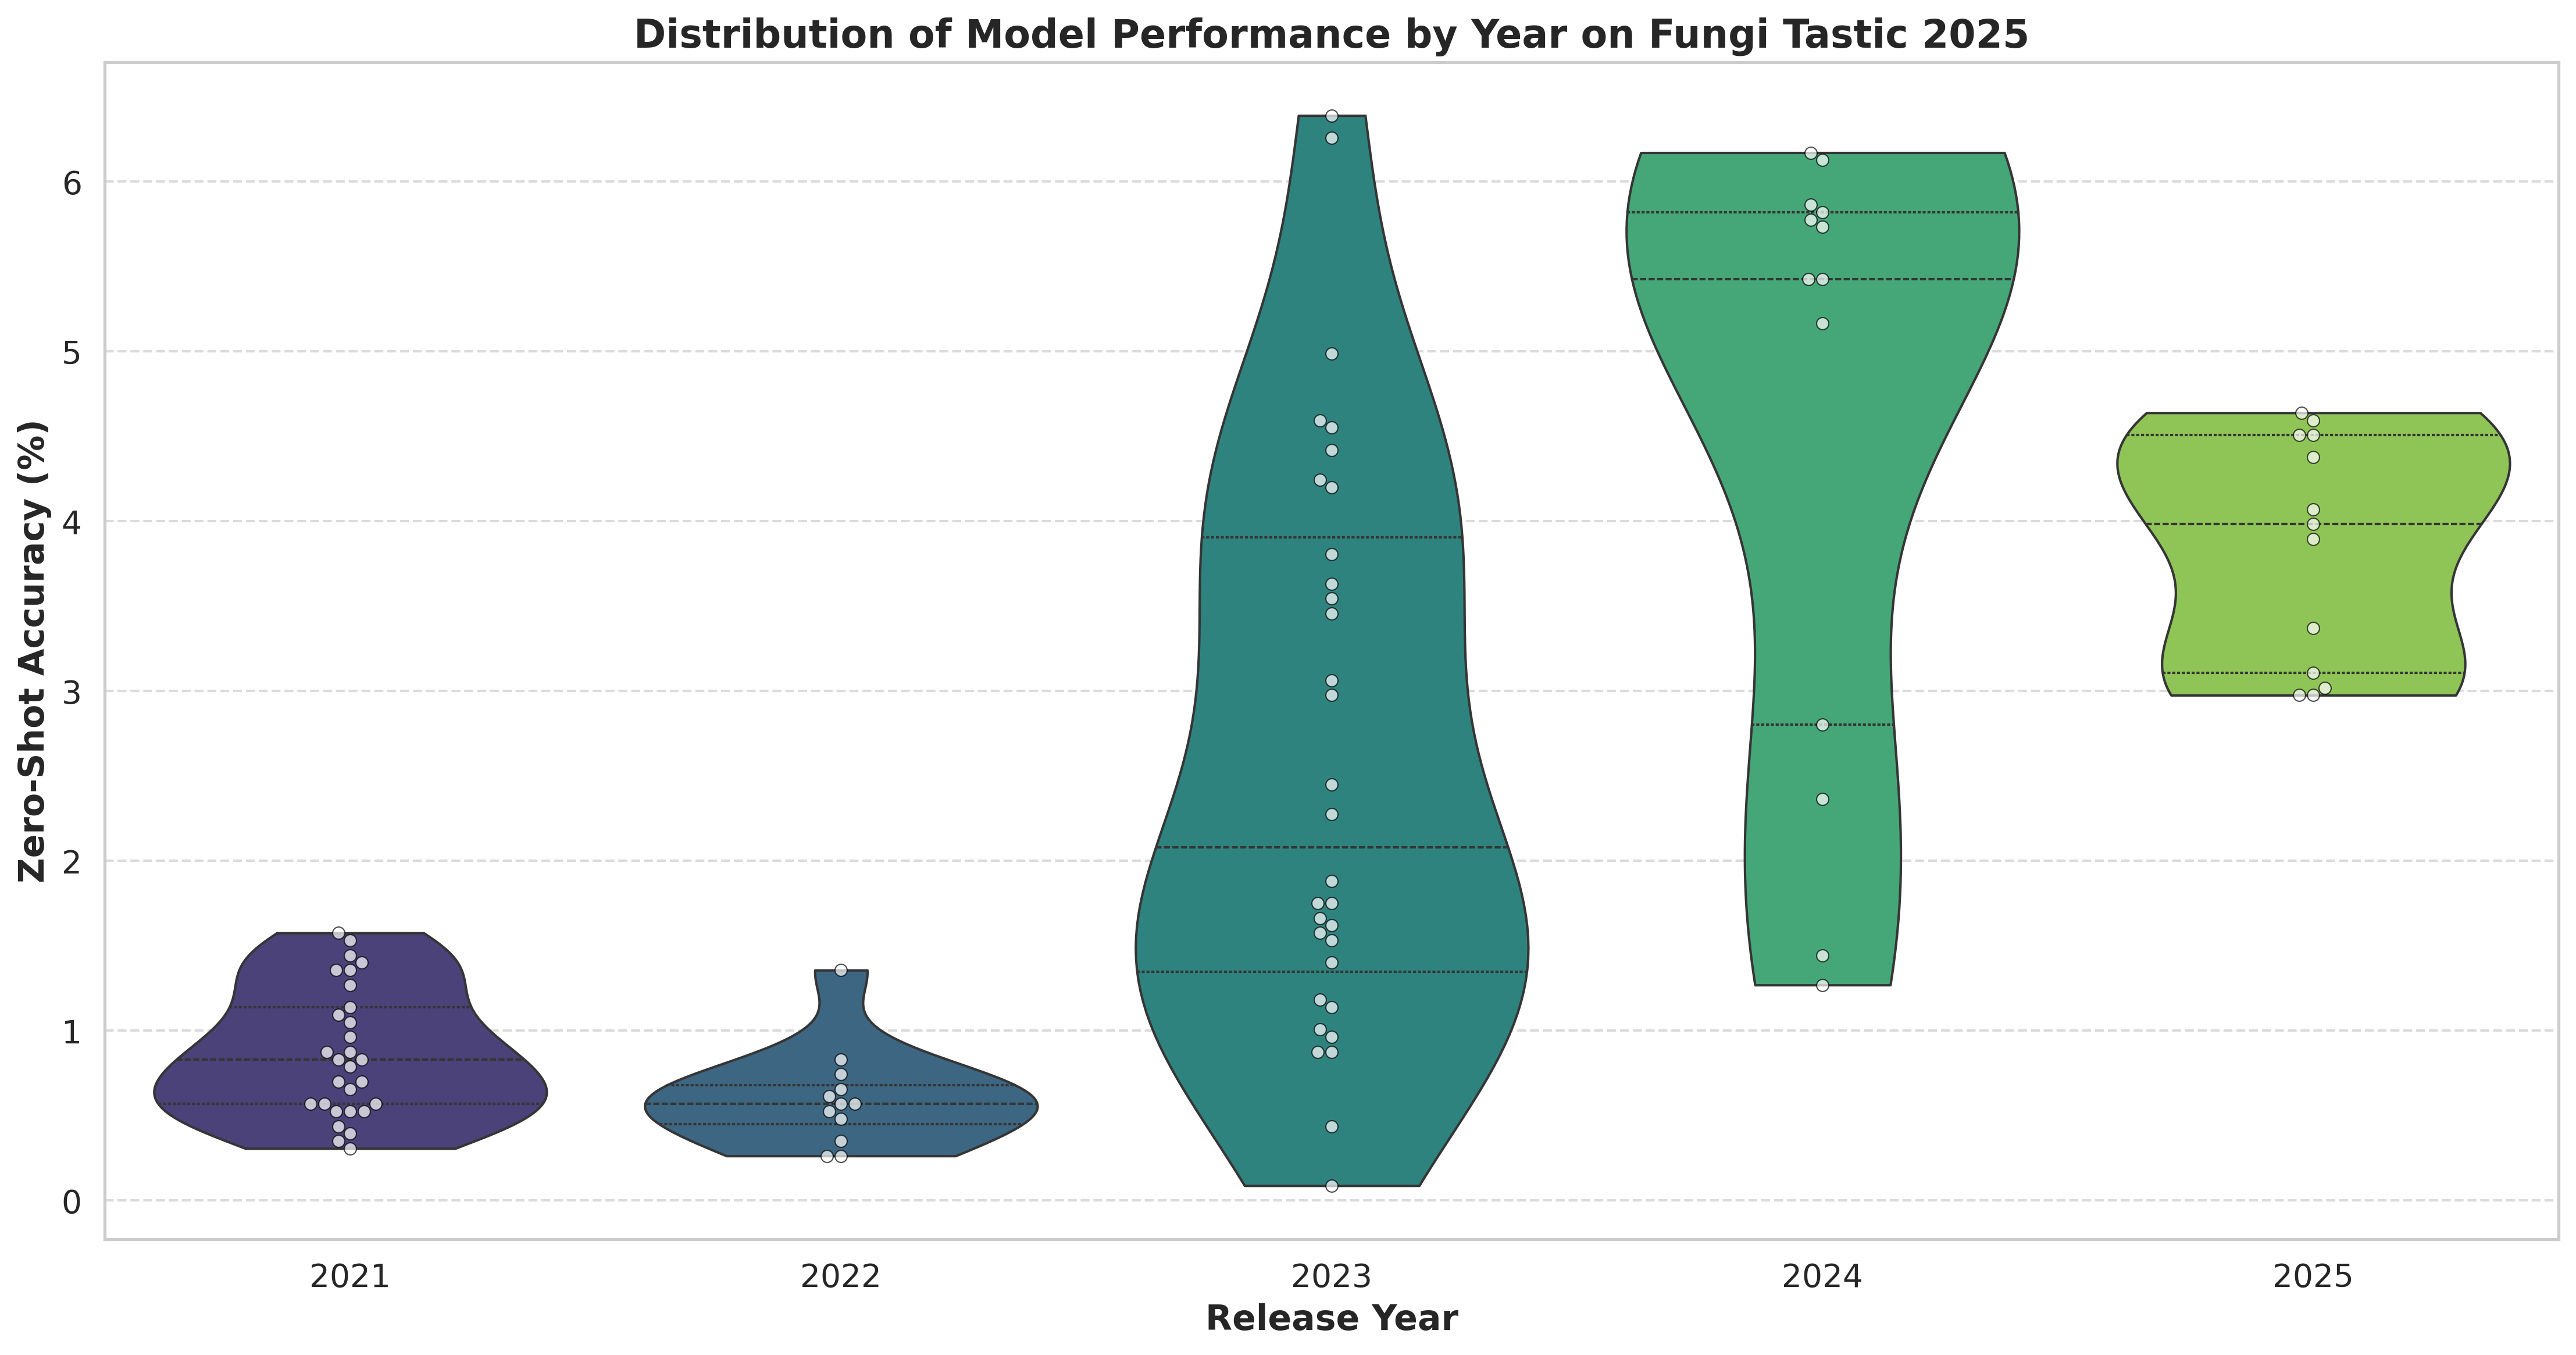

In [9]:
# Prepare the data - group by year for violin plot
plt.figure(figsize=(15, 8), dpi=300)
sns.set(style="whitegrid", font_scale=1.2)

# Create violin plot showing performance distribution by year
ax = sns.violinplot(
    x='year', 
    y='performance',
    data=time_perf,
    palette='viridis',
    inner='quartile',  # Show quartiles inside the violin
    cut=0,  # Limit the violin range to the observed data
    linewidth=1
)

# Add individual data points for better visibility
sns.swarmplot(
    x='year',
    y='performance',
    data=time_perf,
    size=5,
    color='white',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7
)

# Format the plot
plt.xlabel('Release Year', fontweight='bold')
plt.ylabel('Zero-Shot Accuracy (%)', fontweight='bold')
plt.title('Distribution of Model Performance by Year on Fungi Tastic 2025', fontweight='bold', fontsize=16)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add annotations for top models in each year
for year in time_perf['year'].unique():
    top_model = time_perf[time_perf['year'] == year].nlargest(1, 'performance').iloc[0]
    plt.annotate(
        top_model['model_name'],
        xy=(top_model['year'], top_model['performance']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )

plt.tight_layout()
plt.show()
